# Kpler loadings vs Strait of Hormuz crossings

Hull-level join of Kpler crude **Trades / PortCalls** with `soh_crossing_hist.xlsx`.

v1 is load → strait. GoO STS is an **overlay** (`sts_flag`) on the same row — it does not replace `bucket`.

**as_of** is the latest date in the crossing file. Kpler rows after that sit in a pending table until the xlsx catches up — otherwise we would flag missing exits that the file simply has not recorded yet.

| Bucket | Meaning |
|---|---|
| `loaded_no_exit` | Inside-gulf Kpler load, no SoH exit, lag past `ALERT_LAG_DAYS` |
| `load_without_reentry` | SoH last saw an **exit**, then Kpler shows a gulf load — missing inbound |
| `exit_no_load` | Laden crude SoH exit with no matching Kpler load |
| `conflict` | Kpler loaded, SoH recorded a **ballast** exit |
| `inside_laden` / `inside_loading` / `inside_ballast` | Last SoH event is an entry |
| `intra_gulf` | Kpler destination still looks inside the gulf |
| `accounted` | Kpler load then laden SoH exit |
| `bypass` | Fujairah / Sohar / Jask / Yanbu — should not cross Hormuz |

STS overlay: `giver_after_exit` / `receiver_after_exit` (informational), `giver_no_soh` / `unknown_partner` / `sts_inside` (watchlist).


## 1. Run

In [3]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

BASE = Path(r"C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing")
if str(BASE) not in sys.path:
    sys.path.insert(0, str(BASE))

from kpler_vs_soh.config import Settings
from kpler_vs_soh.pipeline import run

# True on the first run of the day, or after updating credentials / date range.
REFRESH_KPLER = False
EXAMPLE_VESSEL = "HASNA"

WATCH_COLS = [
    "vessel_name",
    "imo",
    "bucket",
    "sts_flag",
    "sts_zone",
    "sts_ts",
    "sts_counterparty",
    "sts_lag_days",
    "fleet",
    "afra_class",
    "last_cross_ts",
    "last_cross_dir",
    "loading_state_soh",
    "last_load_ts",
    "last_load_origin",
    "last_load_status",
    "days_inside",
    "days_since_load",
    "volume_bbl",
    "reason",
]

In [4]:
result = run(Settings(), refresh_kpler=REFRESH_KPLER)
state = result.state
alerts = result.alerts
watch = state[state["watchlist"]].copy() if not state.empty else state

print(f"as_of (crossing file): {result.as_of}")
print(f"Kpler window: {result.kpler_start} → {result.kpler_end}")
print(f"Crossings: {len(result.crossings):,}  Loads: {len(result.loads):,}  State hulls: {len(state):,}")
print(f"Watchlist: {len(watch):,}  Alerts vs previous snapshot: {len(alerts):,}")
print(f"Kpler loads after as_of (pending): {len(result.pending):,}")
print(f"GoO STS events: {len(result.sts_events):,}")
if "sts_flag" in state.columns:
    flagged = state["sts_flag"].dropna()
    flagged = flagged[~flagged.astype(str).isin(["", "nan", "<NA>"])]
    print("STS flags:")
    print(flagged.value_counts().to_string() if len(flagged) else "  (none)")
print("Wrote:")
for key, path in result.export_paths.items():
    print(f"  {key}: {path}")

C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\kpler_vs_soh\sts.py:222: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  out = pd.concat([aligned, extra_df], ignore_index=True, sort=False)


as_of (crossing file): 2026-08-16
Kpler window: 2026-04-18 → 2026-08-16
Crossings: 2,946  Loads: 1,061  State hulls: 678
Watchlist: 180  Alerts vs previous snapshot: 0
Kpler loads after as_of (pending): 0
GoO STS events: 289
STS flags:
sts_flag
giver_no_soh           92
unknown_partner        31
receiver_after_exit    24
giver_after_exit        5
Wrote:
  state: C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\kpler_vs_soh\output\vessel_state_latest.csv
  alerts: C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\kpler_vs_soh\output\alerts_latest.csv
  watchlist: C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\kpler_vs_soh\output\watchlist_latest.csv
  sts: C:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\vessel_crossing\kpler_vs_soh\output\sts_overlay_latest.csv


## 2. Inside Hormuz (AFRA–ULCC)

Cargo that could leave if the strait normalizes, and hulls available to load. Universe is last SoH event = still inside, AFRA through ULCC. `intra_gulf` destinations are dropped — those barrels are not Hormuz-releasable. `inside_loading` is folded into laden.

Two clocks: **days since load** for cargo (FS / missed dark exit), **days since entry** for ballast (prompt vs stale supply). Haircut is a single cutoff (`HAIRCUT_DAYS`, default 21). Unknown load dates fail the haircut but stay in the total. Re-run this section only after changing the knob.


as_of 2026-08-16  |  AFRA–ULCC still inside  |  haircut < 21d  |  intra-gulf dropped

Laden (mbbl) — total vs days-since-load haircut


,fleet,hulls,mbbl,hulls_haircut,mbbl_haircut
0,clean fleet,39,67.4,31,53.7
1,dark fleet,9,11.7,4,4.2
2,total,48,79.1,35,58.0


Ballast (VLCC-eq = dwt / 300,000) — total vs days-inside haircut


,fleet,hulls,vlcc_eq,hulls_haircut,vlcc_eq_haircut
0,clean fleet,24,14.2,6,3.7
1,dark fleet,25,20.6,0,0.0
2,total,49,34.8,6,3.7


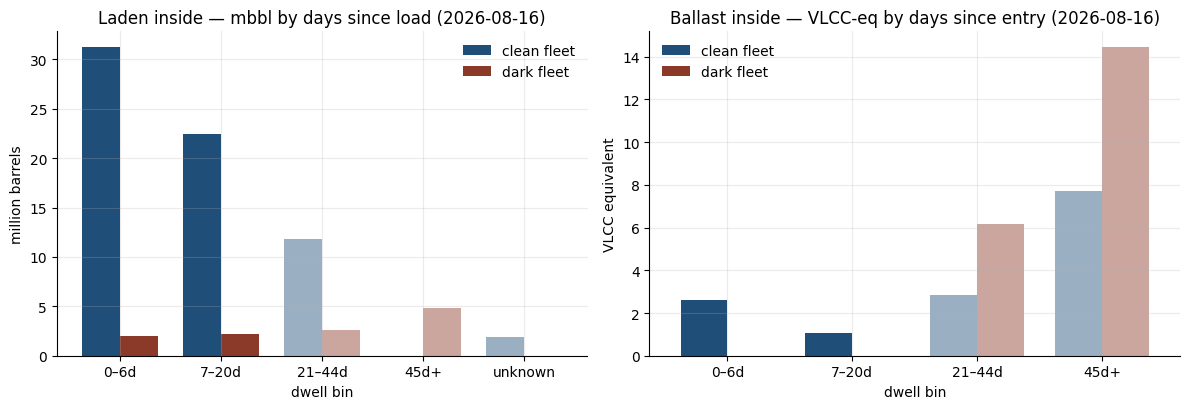

Inside AFRA–ULCC hulls: 97  (laden 48 + ballast 49)
Hulls by class × fleet — all still inside


fleet,clean fleet,dark fleet,all
afra_class,,,
AFRA,14,9,23
LR2,7,1,8
VLCC,40,23,63
ULCC,2,1,3
Above ULCC,0,0,0
total,63,34,97


Hulls by class × fleet — laden (total vs days-since-load haircut)


total                haircut <21d               
fleet      clean fleet dark fleet all  clean fleet dark fleet all
afra_class                                                       
AFRA                 2          4   6            1          3   4
LR2                  2          0   2            2          0   2
VLCC                34          5  39           28          1  29
ULCC                 1          0   1            0          0   0
Above ULCC           0          0   0            0          0   0
total               39          9  48           31          4  35

Hulls by class × fleet — ballast (total vs days-inside haircut)


...

total            haircut <21d           
fleet      clean fleet dark fleet  clean fleet dark fleet
afra_class                                               
AFRA               4.4        1.7          1.1        0.0
LR2                2.5        0.5          0.5        0.0
VLCC               6.1       17.3          2.1        0.0
ULCC               1.2        1.1          0.0        0.0
Above ULCC         0.0        0.0          0.0        0.0

Laden failing haircut (13 hulls) — FS or possible missed dark exit


,vessel_name,imo,bucket,fleet,afra_class,last_load_origin,last_load_dest,days_inside,days_since_load,volume_bbl,deadweight,reason
0,Arhimeda,9197909,loaded_no_exit,dark fleet,VLCC,Kharg Island,None,129.0,118.0,2000002.0,309498.0,Kpler loaded at Kharg Island on 2026-04-20 (In Transit); no SoH exit after that (118d ...
1,Kaviz,9282041,loaded_no_exit,dark fleet,AFRA,Kharg Island,None,110.0,102.0,779772.0,115390.0,Kpler loaded at Kharg Island on 2026-05-06 (PortCall); no SoH exit after that (102d si...
2,Goldcrest,9292486,loaded_no_exit,dark fleet,VLCC,Kharg Island,None,78.0,72.0,2065177.0,306998.0,Kpler loaded at Kharg Island on 2026-06-05 (In Transit); no SoH exit after that (72d s...
3,Barbados Prosperity,9377418,loaded_no_exit,clean fleet,VLCC,Al Basrah,None,46.0,39.0,1980000.0,297958.0,Kpler loaded at Al Basrah on 2026-07-08 (PortCall); no SoH exit after that (39d since ...
4,Sanam,9858486,loaded_no_exit,clean fleet,VLCC,Juaymah,None,40.0,39.0,2065699.0,299999.0,Kpler loaded at Juaymah on 2026-07-08 (In Transit); no SoH exit after that (39d since ...
5,Al Siddeeq,9853486,loaded_no_exit,clean fleet,ULCC,Mina Al-Ahmadi,Lome,51.0,33.0,1079293.0,323514.0,Kpler loaded at Mina Al-Ahmadi on 2026-07-14 (In Transit); no SoH exit after that (33d...
6,Felix,9181194,loaded_no_exit,dark fleet,VLCC,Kharg Island,None,39.0,31.0,2009185.0,308491.0,Kpler loaded at Kharg Island on 2026-07-16 (In Transit); no SoH exit after that (31d s...
7,Habrut,9500730,loaded_no_exit,clean fleet,VLCC,Juaymah,Houston,38.0,29.0,2000002.0,319439.0,Kpler loaded at Juaymah on 2026-07-18 (In Transit); no SoH exit after that (29d since ...
8,Philippines Prosperity,9377420,loaded_no_exit,clean fleet,VLCC,FSO Qatar Petroleum Al Shaheen II,Lianyungang,31.0,25.0,1900000.0,302550.0,Kpler loaded at FSO Qatar Petroleum Al Shaheen II on 2026-07-22 (In Transit); no SoH e...
9,Al Derwazah,9653410,loaded_no_exit,clean fleet,VLCC,Mina Al-Ahmadi,None,27.0,23.0,2000002.0,316884.0,Kpler loaded at Mina Al-Ahmadi on 2026-07-24 (In Transit); no SoH exit after that (23d...


Ballast failing haircut (43 hulls) — not prompt loading supply


,vessel_name,imo,bucket,fleet,afra_class,last_load_origin,last_load_dest,days_inside,days_since_load,volume_bbl,deadweight,vlcc_eq,reason
0,ARNICA,9187643,inside_ballast,dark fleet,AFRA,None,None,196.0,NaN,0.0,99148.0,0.33,Last SoH event is entry on 2026-02-01 ballast/unknown; no Kpler crude load yet.
1,NORTH,9252979,inside_ballast,clean fleet,AFRA,None,None,195.0,NaN,0.0,105250.0,0.35,Last SoH event is entry on 2026-02-02 ballast/unknown; no Kpler crude load yet.
2,FRONT CHEETAH,9686637,inside_ballast,clean fleet,AFRA,None,None,187.0,NaN,0.0,109900.0,0.37,Last SoH event is entry on 2026-02-10 ballast/unknown; no Kpler crude load yet.
3,BAOBAB IVOIRIEN,7389443,inside_ballast,clean fleet,ULCC,None,None,182.0,NaN,0.0,351491.0,1.17,Last SoH event is entry on 2026-02-15 ballast/unknown; no Kpler crude load yet.
4,HYDRA,9294551,inside_ballast,clean fleet,AFRA,None,None,182.0,NaN,0.0,105744.0,0.35,Last SoH event is entry on 2026-02-15 ballast/unknown; no Kpler crude load yet.
5,STAR FOREST,9237632,inside_ballast,dark fleet,VLCC,None,None,178.0,NaN,0.0,318692.0,1.06,Last SoH event is entry on 2026-02-19 ballast/unknown; no Kpler crude load yet.
6,CAPTAIN MICHAEL,9531480,inside_ballast,clean fleet,LR2,None,None,178.0,NaN,0.0,157648.0,0.53,Last SoH event is entry on 2026-02-19 ballast/unknown; no Kpler crude load yet.
7,MARLIN SANTORINI,9835836,inside_ballast,clean fleet,LR2,None,None,178.0,NaN,0.0,156587.0,0.52,Last SoH event is entry on 2026-02-19 ballast/unknown; no Kpler crude load yet.
8,SONANGOL NAMIBE,9325049,inside_ballast,clean fleet,LR2,None,None,173.0,NaN,0.0,158425.0,0.53,Last SoH event is entry on 2026-02-24 ballast/unknown; no Kpler crude load yet.
9,STI ORCHARD,9690834,inside_ballast,clean fleet,AFRA,None,None,173.0,NaN,0.0,109999.0,0.37,Last SoH event is entry on 2026-02-24 ballast/unknown; no Kpler crude load yet.


In [5]:
# Change HAIRCUT_DAYS and re-run this cell only — no need to re-pull Kpler.
HAIRCUT_DAYS = 21
FOCUS_CLASSES = ["AFRA", "LR2", "VLCC", "ULCC", "Above ULCC"]
# 1 VLCC-eq ≈ 300 kdwt (AFRA VLCC band is 160–320 kdwt; 300 is the usual freight unit).
VLCC_DWT = 300_000
LADEN_BUCKETS = {"inside_laden", "inside_loading", "loaded_no_exit"}
VINTAGE_ORDER = ["0–6d", "7–20d", "21–44d", "45d+", "unknown"]
FLEET_COLORS = {"clean fleet": "#1f4e79", "dark fleet": "#8b3a2a"}
CLASS_ORDER = FOCUS_CLASSES

INSIDE_COLS = [
    "vessel_name",
    "imo",
    "bucket",
    "fleet",
    "afra_class",
    "last_load_origin",
    "last_load_dest",
    "days_inside",
    "days_since_load",
    "volume_bbl",
    "deadweight",
    "reason",
]

# Prefer §1 pipeline state; after a kernel restart load the last export so this cell still runs.
if "state" not in globals():
    _csv = BASE / "kpler_vs_soh" / "output" / "vessel_state_latest.csv"
    state = pd.read_csv(_csv)
    _as_of = (
        pd.to_datetime(state["as_of"], errors="coerce").max().date()
        if "as_of" in state.columns
        else "?"
    )
    print(f"Loaded state from {_csv.name} (run §1 to refresh).")
else:
    _as_of = result.as_of


def _num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def _vintage(days) -> str:
    if pd.isna(days):
        return "unknown"
    if days < 7:
        return "0–6d"
    if days < 21:
        return "7–20d"
    if days < 45:
        return "21–44d"
    return "45d+"


def _show(df: pd.DataFrame, cols: list[str] | None = None) -> None:
    use = cols or INSIDE_COLS
    keep = [c for c in use if c in df.columns]
    display(df[keep].reset_index(drop=True))


inside = state.copy()
inside["volume_bbl"] = _num(inside["volume_bbl"])
inside["days_inside"] = _num(inside["days_inside"])
inside["days_since_load"] = _num(inside["days_since_load"])
inside["deadweight"] = _num(inside["deadweight"])
inside = inside[
    (inside["soh_pos"] == "inside")
    & inside["afra_class"].isin(FOCUS_CLASSES)
    & (inside["bucket"] != "intra_gulf")
].copy()

laden = inside[inside["bucket"].isin(LADEN_BUCKETS)].copy()
ballast = inside[inside["bucket"] == "inside_ballast"].copy()
laden["mbbl"] = laden["volume_bbl"].fillna(0) / 1e6
ballast["vlcc_eq"] = ballast["deadweight"].fillna(0) / VLCC_DWT
# Cargo clock = time since load; ballast clock = time since last MEG entry.
laden["vintage"] = laden["days_since_load"].map(_vintage)
ballast["vintage"] = ballast["days_inside"].map(_vintage)
laden_ok = laden["days_since_load"].notna() & (laden["days_since_load"] < HAIRCUT_DAYS)
ballast_ok = ballast["days_inside"].notna() & (ballast["days_inside"] < HAIRCUT_DAYS)
laden["haircut_ok"] = laden_ok
ballast["haircut_ok"] = ballast_ok


def _fleet_kpi(df: pd.DataFrame, value: str, ok: pd.Series) -> pd.DataFrame:
    rows = []
    fleets = ["clean fleet", "dark fleet"]
    for fleet in fleets + ["total"]:
        mask = pd.Series(True, index=df.index) if fleet == "total" else df["fleet"] == fleet
        sub = df[mask]
        sub_ok = ok[mask]
        rows.append(
            {
                "fleet": fleet,
                "hulls": int(sub["imo"].nunique()),
                value: float(sub[value].sum()),
                "hulls_haircut": int(sub.loc[sub_ok, "imo"].nunique()),
                f"{value}_haircut": float(sub.loc[sub_ok, value].sum()),
            }
        )
    return pd.DataFrame(rows)


print(f"as_of {_as_of}  |  AFRA–ULCC still inside  |  haircut < {HAIRCUT_DAYS}d  |  intra-gulf dropped")
print()
laden_kpi = _fleet_kpi(laden, "mbbl", laden_ok)
ballast_kpi = _fleet_kpi(ballast, "vlcc_eq", ballast_ok)
print("Laden (mbbl) — total vs days-since-load haircut")
display(laden_kpi.round(1))
print("Ballast (VLCC-eq = dwt / 300,000) — total vs days-inside haircut")
display(ballast_kpi.round(1))


def _vintage_bar(df: pd.DataFrame, value: str, ax, title: str, ylabel: str) -> None:
    pivot = (
        df.pivot_table(index="vintage", columns="fleet", values=value, aggfunc="sum")
        .reindex(VINTAGE_ORDER)
        .reindex(columns=["clean fleet", "dark fleet"])
        .fillna(0)
    )
    pivot = pivot.loc[pivot.sum(axis=1) > 0]
    colors = [FLEET_COLORS.get(c, "#555") for c in pivot.columns]
    pivot.plot(kind="bar", ax=ax, color=colors, rot=0, width=0.75)
    ax.set_title(title)
    ax.set_xlabel("dwell bin")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False, title=None)
    # Bins at/after 21d are the low-confidence pile at the default haircut.
    for i, label in enumerate(pivot.index):
        if label in {"21–44d", "45d+", "unknown"}:
            for bar in ax.containers:
                if i < len(bar):
                    bar[i].set_alpha(0.45)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
_vintage_bar(
    laden,
    "mbbl",
    axes[0],
    f"Laden inside — mbbl by days since load ({result.as_of})",
    "million barrels",
)
_vintage_bar(
    ballast,
    "vlcc_eq",
    axes[1],
    f"Ballast inside — VLCC-eq by days since entry ({result.as_of})",
    "VLCC equivalent",
)
fig.tight_layout()
plt.show()


def _class_grid(df: pd.DataFrame, value: str, ok: pd.Series) -> pd.DataFrame:
    total = (
        df.pivot_table(index="afra_class", columns="fleet", values=value, aggfunc="sum")
        .reindex(CLASS_ORDER)
        .reindex(columns=["clean fleet", "dark fleet"])
        .fillna(0)
    )
    cut = (
        df[ok]
        .pivot_table(index="afra_class", columns="fleet", values=value, aggfunc="sum")
        .reindex(CLASS_ORDER)
        .reindex(columns=["clean fleet", "dark fleet"])
        .fillna(0)
    )
    total.columns = pd.MultiIndex.from_product([["total"], total.columns])
    cut.columns = pd.MultiIndex.from_product([[f"haircut <{HAIRCUT_DAYS}d"], cut.columns])
    return pd.concat([total, cut], axis=1)


def _hull_grid(df: pd.DataFrame, ok: pd.Series | None = None) -> pd.DataFrame:
    """Hull counts by AFRA class × fleet; optional haircut columns when ok is passed."""
    total = (
        df.pivot_table(index="afra_class", columns="fleet", values="imo", aggfunc="nunique")
        .reindex(CLASS_ORDER)
        .reindex(columns=["clean fleet", "dark fleet"])
        .fillna(0)
        .astype(int)
    )
    total["all"] = total.sum(axis=1)
    if ok is None:
        out = total.copy()
        out.loc["total"] = out.sum(axis=0)
        return out
    cut = (
        df[ok]
        .pivot_table(index="afra_class", columns="fleet", values="imo", aggfunc="nunique")
        .reindex(CLASS_ORDER)
        .reindex(columns=["clean fleet", "dark fleet"])
        .fillna(0)
        .astype(int)
    )
    cut["all"] = cut.sum(axis=1)
    total.columns = pd.MultiIndex.from_product([["total"], total.columns])
    cut.columns = pd.MultiIndex.from_product([[f"haircut <{HAIRCUT_DAYS}d"], cut.columns])
    out = pd.concat([total, cut], axis=1)
    out.loc["total"] = out.sum(axis=0)
    return out


# Reconciles the CSV filter: soh_pos=inside ∩ AFRA–ULCC = laden + ballast.
print(
    f"Inside AFRA–ULCC hulls: {len(inside)}  "
    f"(laden {len(laden)} + ballast {len(ballast)})"
)
print("Hulls by class × fleet — all still inside")
display(_hull_grid(inside))
print("Hulls by class × fleet — laden (total vs days-since-load haircut)")
display(_hull_grid(laden, laden_ok))
print("Hulls by class × fleet — ballast (total vs days-inside haircut)")
display(_hull_grid(ballast, ballast_ok))

print("Laden mbbl by class")
display(_class_grid(laden, "mbbl", laden_ok).round(1))
print("Ballast VLCC-eq by class")
display(_class_grid(ballast, "vlcc_eq", ballast_ok).round(1))

stale_laden = laden[~laden_ok].sort_values(["days_since_load", "days_inside"], ascending=False)
stale_ballast = ballast[~ballast_ok].sort_values("days_inside", ascending=False)
print(f"Laden failing haircut ({len(stale_laden)} hulls) — FS or possible missed dark exit")
_show(stale_laden)
print(f"Ballast failing haircut ({len(stale_ballast)} hulls) — not prompt loading supply")
_show(
    stale_ballast.assign(vlcc_eq=lambda d: (d["deadweight"].fillna(0) / VLCC_DWT).round(2)),
    INSIDE_COLS[:-1] + ["vlcc_eq", "reason"],
)


## 3. Book

,bucket,vessels,dark,mbbl,median_days_since_load
7,loaded_no_exit,34,14,48.588939,23.0
3,exit_no_load,52,5,90.278679,46.0
2,conflict,1,0,0.678003,118.0
5,inside_laden,23,1,39.105647,2.0
4,inside_ballast,189,58,8.759317,18.0
6,intra_gulf,2,1,0.358261,41.5
0,accounted,87,28,131.580952,44.0
1,bypass,229,4,330.363259,36.0
8,outside_other,61,1,0.008944,10.0


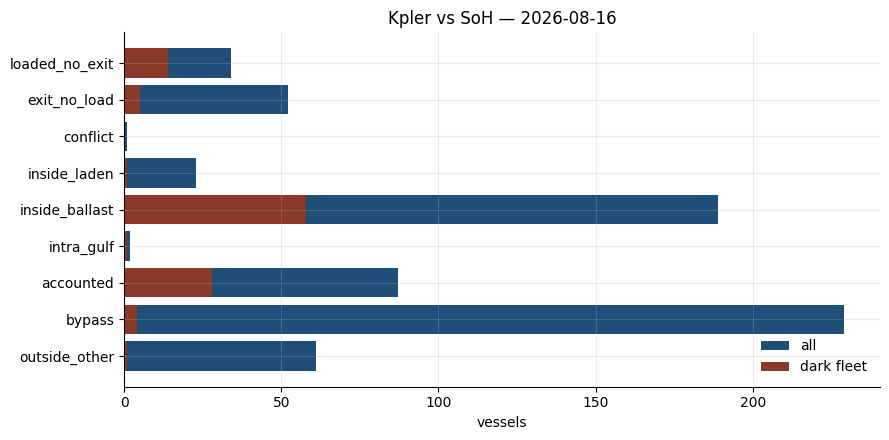

In [6]:
display(result.summary)

if result.summary.empty:
    print("No vessels classified — check the crossing file and Kpler pull.")
else:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    plot = result.summary.dropna(subset=["bucket"]).copy()
    y = range(len(plot))
    ax.barh(list(y), plot["vessels"], color="#1f4e79", label="all")
    ax.barh(list(y), plot["dark"], color="#8b3a2a", label="dark fleet")
    ax.set_yticks(list(y), plot["bucket"].astype(str))
    ax.invert_yaxis()
    ax.set_xlabel("vessels")
    ax.set_title(f"Kpler vs SoH — {result.as_of}")
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    plt.show()

## 4. Watchlist

These are the dark-activity / mismatch buckets. `inside_laden` within 7 days is the normal steaming queue; `loaded_no_exit` is the same idea gone stale.

`bypass` (Fujairah / Oman / Yanbu / Jask) is the control set: Kpler loaded them, and they should never appear as missing SoH exits.

In [7]:
def show_bucket(name: str) -> None:
    sub = watch[watch["bucket"] == name].copy()
    print(f"\n=== {name}: {len(sub)} ===")
    if sub.empty:
        return
    cols = [c for c in WATCH_COLS if c in sub.columns]
    display(sub[cols].reset_index(drop=True))


for bucket in [
    "loaded_no_exit",
    "load_without_reentry",
    "exit_no_load",
    "conflict",
    "inside_laden",
    "inside_loading",
]:
    show_bucket(bucket)

bypass = state[state["bucket"] == "bypass"].copy()
print(f"\n=== bypass (control): {len(bypass)} ===")
if not bypass.empty:
    print(bypass["last_load_origin"].value_counts().head(12).to_string())

sts_watch = ["giver_no_soh", "unknown_partner", "sts_inside"]
print("\n=== STS overlay on watchlist ===")
sts_rows = state[state["sts_flag"].isin(sts_watch)].copy()
print(sts_rows["sts_flag"].value_counts().to_string() if not sts_rows.empty else "(none)")
if not sts_rows.empty:
    cols = [c for c in WATCH_COLS if c in sts_rows.columns]
    ordered = sts_rows.sort_values(["sts_flag", "sts_ts"], na_position="last")
    display(ordered[cols].reset_index(drop=True))


=== loaded_no_exit: 34 ===


,vessel_name,imo,bucket,sts_flag,sts_zone,sts_ts,sts_counterparty,sts_lag_days,fleet,afra_class,last_cross_ts,last_cross_dir,loading_state_soh,last_load_ts,last_load_origin,last_load_status,days_inside,days_since_load,volume_bbl,reason
0,Arhimeda,9197909,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,VLCC,2026-04-09,Entered MEG,Ballast,2026-04-20 00:00:00,Kharg Island,In Transit,129.0,118.0,2000002.0,Kpler loaded at Kharg Island on 2026-04-20 (In Transit); no SoH exit after that (118d ...
1,Kaviz,9282041,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,AFRA,2026-04-28,Entered MEG,Ballast,2026-05-06 00:00:00,Kharg Island,PortCall,110.0,102.0,779772.0,Kpler loaded at Kharg Island on 2026-05-06 (PortCall); no SoH exit after that (102d si...
2,Niovi,9292498,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,None,NaT,None,None,2026-05-06 00:00:00,Kharg Island,In Transit,NaN,102.0,999998.0,Never in the SoH crossing file. Kpler loaded at Kharg Island on 2026-05-06 (In Transit...
3,Goldcrest,9292486,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,VLCC,2026-05-30,Entered MEG,Ballast,2026-06-05 00:00:00,Kharg Island,In Transit,78.0,72.0,2065177.0,Kpler loaded at Kharg Island on 2026-06-05 (In Transit); no SoH exit after that (72d s...
4,Fortune,9283746,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,None,NaT,None,None,2026-06-10 00:00:00,Kharg Island,PortCall,NaN,67.0,247013.0,Never in the SoH crossing file. Kpler loaded at Kharg Island on 2026-06-10 (PortCall);...
5,Singapore Loyalty,9322293,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,None,NaT,None,None,2026-07-03 00:35:00,Al Basrah,PortCall,NaN,44.0,1899994.0,Never in the SoH crossing file. Kpler loaded at Al Basrah on 2026-07-03 (PortCall); no...
6,Barbados Prosperity,9377418,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-07-01,Entered MEG,Ballast,2026-07-08 12:18:00,Al Basrah,PortCall,46.0,39.0,1980000.0,Kpler loaded at Al Basrah on 2026-07-08 (PortCall); no SoH exit after that (39d since ...
7,Sanam,9858486,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-07-07,Entered MEG,Ballast,2026-07-08 18:13:00,Juaymah,In Transit,40.0,39.0,2065699.0,Kpler loaded at Juaymah on 2026-07-08 (In Transit); no SoH exit after that (39d since ...
8,Nasha,9079107,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,None,NaT,None,None,2026-07-14 00:00:00,Kharg Island,In Transit,NaN,33.0,2000002.0,Never in the SoH crossing file. Kpler loaded at Kharg Island on 2026-07-14 (In Transit...
9,Aditya,9203784,loaded_no_exit,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,None,NaT,None,None,2026-07-14 00:00:00,Kharg Island,In Transit,NaN,33.0,1083338.0,Never in the SoH crossing file. Kpler loaded at Kharg Island on 2026-07-14 (In Transit...



=== load_without_reentry: 0 ===

=== exit_no_load: 52 ===


,vessel_name,imo,bucket,sts_flag,sts_zone,sts_ts,sts_counterparty,sts_lag_days,fleet,afra_class,last_cross_ts,last_cross_dir,loading_state_soh,last_load_ts,last_load_origin,last_load_status,days_inside,days_since_load,volume_bbl,reason
0,GRAND LADY,9406166,exit_no_load,receiver_after_exit,Fujairah Light,2026-08-07 00:00:00,Giannis,3,clean fleet,VLCC,2026-08-04,Exited MEG,Laden,2026-07-01 00:00:00,Al Basrah,Delivered,NaN,46.0,1074079.0,SoH laden crude exit on 2026-08-04 with no matching inside-gulf Kpler load in the 21d ...
1,HAFEET,9928009,exit_no_load,receiver_after_exit,Fujairah Light,2026-08-05 00:00:00,Monaco Loyalty,13,clean fleet,VLCC,2026-07-23,Exited MEG,Laden,2026-07-01 15:59:00,Umm Lulu,Delivered,NaN,46.0,1996461.0,SoH laden crude exit on 2026-07-23 with no matching inside-gulf Kpler load in the 21d ...
2,VADIN,9324100,exit_no_load,receiver_after_exit,Fujairah Light,2026-08-12 19:19:00,Front Spey,2,clean fleet,VLCC,2026-08-10,Exited MEG,Laden,2026-07-06 01:33:00,Mina Al-Ahmadi,Delivered,NaN,41.0,2000002.0,SoH laden crude exit on 2026-08-10 with no matching inside-gulf Kpler load in the 21d ...
3,STOIC WARRIOR,1028762,exit_no_load,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR2,2026-06-25,Exited MEG,Laden,NaT,None,None,NaN,NaN,1012911.0,SoH laden crude exit on 2026-06-25 with no matching inside-gulf Kpler load in the 21d ...
4,SINOPA,9172038,exit_no_load,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,LR2,2026-07-14,Exited MEG,Laden,NaT,None,None,NaN,NaN,1015490.0,SoH laden crude exit on 2026-07-14 with no matching inside-gulf Kpler load in the 21d ...
5,STAR LINE,9237618,exit_no_load,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,AFRA,2026-06-23,Exited MEG,Laden,NaT,None,None,NaN,NaN,716208.0,SoH laden crude exit on 2026-06-23 with no matching inside-gulf Kpler load in the 21d ...
6,OBA,9239848,exit_no_load,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR2,2026-06-21,Exited MEG,Laden,NaT,None,None,NaN,NaN,734996.0,SoH laden crude exit on 2026-06-21 with no matching inside-gulf Kpler load in the 21d ...
7,URI,9248497,exit_no_load,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,VLCC,2026-06-21,Exited MEG,Laden,NaT,None,None,NaN,NaN,2000002.0,SoH laden crude exit on 2026-06-21 with no matching inside-gulf Kpler load in the 21d ...
8,DESH VAIBHAV,9297498,exit_no_load,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-06-19,Exited MEG,Laden,NaT,None,None,NaN,NaN,2013123.0,SoH laden crude exit on 2026-06-19 with no matching inside-gulf Kpler load in the 21d ...
9,TOWADA,9321213,exit_no_load,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-07-07,Exited MEG,Laden,NaT,None,None,NaN,NaN,2099998.0,SoH laden crude exit on 2026-07-07 with no matching inside-gulf Kpler load in the 21d ...



=== conflict: 1 ===


,vessel_name,imo,bucket,sts_flag,sts_zone,sts_ts,sts_counterparty,sts_lag_days,fleet,afra_class,last_cross_ts,last_cross_dir,loading_state_soh,last_load_ts,last_load_origin,last_load_status,days_inside,days_since_load,volume_bbl,reason
0,DAFFODIL,9239927,conflict,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,AFRA,2026-06-21,Exited MEG,Ballast,2026-04-20 19:19:00,MAA Refinery,Delivered,NaN,118.0,678003.0,Kpler loaded at MAA Refinery on 2026-04-20 but SoH recorded a ballast exit on 2026-06-21.



=== inside_laden: 23 ===


,vessel_name,imo,bucket,sts_flag,sts_zone,sts_ts,sts_counterparty,sts_lag_days,fleet,afra_class,last_cross_ts,last_cross_dir,loading_state_soh,last_load_ts,last_load_origin,last_load_status,days_inside,days_since_load,volume_bbl,reason
0,South Africa Prosperity,9526461,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-06-22,Entered MEG,Ballast,2026-08-09 00:00:00,Al Basrah,In Transit,55.0,7.0,1900000.0,Kpler loaded at Al Basrah on 2026-08-09 (In Transit); no SoH exit after that (7d since...
1,Das,9854507,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-06,Entered MEG,Ballast,2026-08-09 00:00:00,Das Island,In Transit,10.0,7.0,1996429.0,Kpler loaded at Das Island on 2026-08-09 (In Transit); no SoH exit after that (7d sinc...
2,Panama Prosperity,9514561,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-04,Entered MEG,Ballast,2026-08-10 06:39:00,Al Basrah,In Transit,12.0,6.0,2007034.0,Kpler loaded at Al Basrah on 2026-08-10 (In Transit); no SoH exit after that (6d since...
3,Indonesia Prosperity,9595228,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-07,Entered MEG,Ballast,2026-08-10 16:38:00,Al Basrah,PortCall,9.0,6.0,1459997.0,Kpler loaded at Al Basrah on 2026-08-10 (PortCall); no SoH exit after that (6d since l...
4,Malaysia Prosperity,9395305,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-08,Entered MEG,Ballast,2026-08-12 00:00:00,Juaymah,In Transit,8.0,4.0,2000002.0,Kpler loaded at Juaymah on 2026-08-12 (In Transit); no SoH exit after that (4d since l...
5,Al Salmi,9534793,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-07-13,Entered MEG,Ballast,2026-08-12 00:00:00,Mina Al-Ahmadi,In Transit,34.0,4.0,2000002.0,Kpler loaded at Mina Al-Ahmadi on 2026-08-12 (In Transit); no SoH exit after that (4d ...
6,Montestena,9585883,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR2,2026-07-30,Entered MEG,Ballast,2026-08-12 00:00:00,Al Basrah,In Transit,17.0,4.0,980002.0,Kpler loaded at Al Basrah on 2026-08-12 (In Transit); no SoH exit after that (4d since...
7,Al Kout,9653434,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-08,Entered MEG,Ballast,2026-08-12 00:00:00,Mina Al-Ahmadi,In Transit,8.0,4.0,2000002.0,Kpler loaded at Mina Al-Ahmadi on 2026-08-12 (In Transit); no SoH exit after that (4d ...
8,Fiji Prosperity,9740330,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-08,Entered MEG,Ballast,2026-08-13 07:39:00,Halul Island,In Transit,8.0,3.0,1067645.0,Kpler loaded at Halul Island on 2026-08-13 (In Transit); no SoH exit after that (3d si...
9,Romania Prosperity,9315161,inside_laden,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-11,Entered MEG,Ballast,2026-08-14 00:00:00,Das Island,In Transit,5.0,2.0,2000002.0,Kpler loaded at Das Island on 2026-08-14 (In Transit); no SoH exit after that (2d sinc...



=== inside_loading: 0 ===

=== bypass (control): 229 ===
last_load_origin
ADCOP Fujairah                   56
Muajjiz                          44
Mina Al Fahal                    31
Fujairah Light.                  30
Sohar Light.                     29
Yanbu Crude                      28
Yanbu                             5
Jask Oil Terminal                 4
FOTT                              1
Sultan Qaboos (Muscat) Light.     1

=== STS overlay on watchlist ===
sts_flag
giver_no_soh       92
unknown_partner    31


,vessel_name,imo,bucket,sts_flag,sts_zone,sts_ts,sts_counterparty,sts_lag_days,fleet,afra_class,last_cross_ts,last_cross_dir,loading_state_soh,last_load_ts,last_load_origin,last_load_status,days_inside,days_since_load,volume_bbl,reason
0,Front Surna,1087512,bypass,giver_no_soh,Fujairah Light,2026-06-18 00:00:00,Cameroon Prosperity,None,clean fleet,None,NaT,None,None,2026-06-19 00:00:00,Fujairah Light.,PortCall,NaN,58.0,2000002.0,Kpler load at Fujairah Light. is east/Red Sea — no SoH exit expected.
1,Nissos Rhenia,9845685,bypass,giver_no_soh,Sohar Light,2026-06-20 00:00:00,Al Funtas,None,clean fleet,None,NaT,None,None,2026-06-21 00:00:00,Sohar Light.,PortCall,NaN,56.0,2000002.0,Kpler load at Sohar Light. is east/Red Sea — no SoH exit expected.
2,Bidbid,1085473,bypass,giver_no_soh,Fujairah Light,2026-06-21 00:00:00,Fujairah Energy,None,clean fleet,None,NaT,None,None,2026-06-22 00:00:00,Fujairah Light.,PortCall,NaN,55.0,1900000.0,Kpler load at Fujairah Light. is east/Red Sea — no SoH exit expected.
3,Maran Mira,9870800,bypass,giver_no_soh,Fujairah Light,2026-06-21 00:00:00,Al Riqqa,None,clean fleet,None,NaT,None,None,2026-06-22 00:00:00,Fujairah Light.,PortCall,NaN,55.0,1854110.0,Kpler load at Fujairah Light. is east/Red Sea — no SoH exit expected.
4,Maran Ajax,9790270,bypass,giver_no_soh,Fujairah Light,2026-06-21 00:00:00,Cameroon Prosperity,None,clean fleet,None,NaT,None,None,2026-08-07 06:38:00,ADCOP Fujairah,Delivered,NaN,9.0,2135290.0,Kpler load at ADCOP Fujairah is east/Red Sea — no SoH exit expected.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,Novo,9633446,bypass,unknown_partner,Gulf of Oman,2026-08-09 00:00:00,<NA>,None,clean fleet,None,NaT,None,None,2026-05-17 02:33:00,ADCOP Fujairah,Delivered,NaN,91.0,799994.0,Kpler load at ADCOP Fujairah is east/Red Sea — no SoH exit expected.
119,Universal Frontier,9829382,outside_other,unknown_partner,Gulf of Oman,2026-08-13 00:00:00,<NA>,None,clean fleet,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,GoO STS with no SoH tape and no inside-gulf Kpler load.
120,Advantage Verdict,9933535,outside_other,unknown_partner,Gulf of Oman,2026-08-13 00:00:00,<NA>,None,clean fleet,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,GoO STS with no SoH tape and no inside-gulf Kpler load.
121,Olympic Life,9844277,bypass,unknown_partner,Gulf of Oman,2026-08-15 00:00:00,<NA>,None,clean fleet,None,NaT,None,None,2026-05-26 01:57:00,ADCOP Fujairah,Delivered,NaN,82.0,607155.0,Kpler load at ADCOP Fujairah is east/Red Sea — no SoH exit expected.


## 4b. STS overlay

Does not change `bucket`. `giver_after_exit` / `receiver_after_exit` are informational. Watchlist STS flags: `giver_no_soh` (excluding Fujairah/Yanbu bypass loaders), `unknown_partner`, `sts_inside`.

In [8]:
sts_all = state[state["sts_flag"].notna()].copy()
sts_all = sts_all[~sts_all["sts_flag"].astype(str).isin(["", "nan", "<NA>"])]
print(f"Hulls with an STS flag: {len(sts_all):,}  (of {len(state):,})")
if sts_all.empty:
    print("No STS overlay this run.")
else:
    print(sts_all.groupby(["sts_flag", "bucket"], dropna=False).size().reset_index(name="n").to_string(index=False))
    cols = [c for c in WATCH_COLS if c in sts_all.columns]
    ordered = sts_all.sort_values(["sts_flag", "sts_lag_days"], ascending=[True, False], na_position="last")
    display(ordered[cols].reset_index(drop=True))

Hulls with an STS flag: 152  (of 678)
           sts_flag        bucket  n
   giver_after_exit     accounted  2
   giver_after_exit  exit_no_load  3
       giver_no_soh        bypass 52
       giver_no_soh outside_other 40
receiver_after_exit     accounted 20
receiver_after_exit  exit_no_load  3
receiver_after_exit outside_other  1
    unknown_partner        bypass 10
    unknown_partner  exit_no_load  1
    unknown_partner outside_other 20


,vessel_name,imo,bucket,sts_flag,sts_zone,sts_ts,sts_counterparty,sts_lag_days,fleet,afra_class,last_cross_ts,last_cross_dir,loading_state_soh,last_load_ts,last_load_origin,last_load_status,days_inside,days_since_load,volume_bbl,reason
0,PLATA CARRIER,9358280,exit_no_load,giver_after_exit,Fujairah Light,2026-08-15 00:00:00,Bahamas Prosperity,52,clean fleet,VLCC,2026-06-24,Exited MEG,Laden,NaT,None,None,NaN,NaN,2057944.0,SoH laden crude exit on 2026-06-24 with no matching inside-gulf Kpler load in the 21d ...
1,MONACO LOYALTY,9312511,accounted,giver_after_exit,Fujairah Light,2026-08-05 00:00:00,Hafeet,45,clean fleet,VLCC,2026-06-21,Exited MEG,Laden,2026-06-01 12:54:00,FSO Qatar Petroleum Al Shaheen I,Delivered,NaN,76.0,2057944.0,Kpler loaded at FSO Qatar Petroleum Al Shaheen I on 2026-06-01 then SoH laden exit on ...
2,AGIOS FANOURIOS I,9759824,accounted,giver_after_exit,Fujairah Light,2026-06-23 09:59:00,V.Advance,44,clean fleet,VLCC,2026-05-10,Exited MEG,Laden,2026-04-20 04:57:00,Al Basrah,Delivered,NaN,118.0,1966754.0,Kpler loaded at Al Basrah on 2026-04-20 then SoH laden exit on 2026-05-10.
3,MONTE URBASA,9785835,exit_no_load,giver_after_exit,Fujairah Light,2026-07-25 18:39:00,Nissos Kea,32,clean fleet,LR2,2026-06-23,Exited MEG,Laden,NaT,None,None,NaN,NaN,999998.0,SoH laden crude exit on 2026-06-23 with no matching inside-gulf Kpler load in the 21d ...
4,OMEGA TRADER,9567659,exit_no_load,giver_after_exit,Fujairah Light,2026-08-05 00:00:00,Umm Al Aish,30,clean fleet,VLCC,2026-07-06,Exited MEG,Laden,NaT,None,None,NaN,NaN,1990649.0,SoH laden crude exit on 2026-07-06 with no matching inside-gulf Kpler load in the 21d ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Angola Prosperity,9896414,outside_other,unknown_partner,Gulf of Oman,2026-06-27 00:00:00,<NA>,None,clean fleet,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,GoO STS with no SoH tape and no inside-gulf Kpler load.
148,Nissos Nikouria,9920760,outside_other,unknown_partner,Gulf of Oman,2026-07-29 00:00:00,<NA>,None,clean fleet,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,GoO STS with no SoH tape and no inside-gulf Kpler load.
149,Caspar,9926661,outside_other,unknown_partner,Gulf of Oman,2026-07-29 00:00:00,<NA>,None,clean fleet,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,GoO STS with no SoH tape and no inside-gulf Kpler load.
150,Maran Dione,9930806,outside_other,unknown_partner,Gulf of Oman,2026-08-04 00:00:00,<NA>,None,clean fleet,NaN,NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,GoO STS with no SoH tape and no inside-gulf Kpler load.


## 5. Changes vs previous snapshot

Empty on the first run. Re-run after a new crossing-file drop to see who entered/left the watchlist.

In [9]:
if alerts.empty:
    print("No previous snapshot to diff (baseline).")
else:
    print(alerts["alert_type"].value_counts().to_string())
    display(alerts.sort_values(["alert_type", "days_since_load"], ascending=[True, False]).reset_index(drop=True))

No previous snapshot to diff (baseline).


## 6. Pending Kpler (after crossing-file as_of)

Do not treat these as missing exits until `soh_crossing_hist.xlsx` includes the same dates.

In [10]:
pending_cols = [
    c for c in [
        "vessel_name", "vessel_imo", "origin_location_name", "destination_location_name",
        "status", "load_ts", "volume_bbl", "origin_bucket", "source",
    ] if c in result.pending.columns
]
if result.pending.empty:
    print("No inside-gulf Kpler loads after as_of.")
else:
    display(result.pending[pending_cols].sort_values("load_ts").reset_index(drop=True))

No inside-gulf Kpler loads after as_of.


## 7. Still inside, no crude load yet

Ballast entries waiting to load. Default view is crude-capable hulls so product MRs do not dominate.

In [11]:
ballast = state[state["bucket"] == "inside_ballast"].copy()
crude_ballast = ballast[ballast["crude_relevant"]]
print(f"inside_ballast: {len(ballast):,}  (crude-relevant {len(crude_ballast):,})")
cols = [c for c in WATCH_COLS if c in crude_ballast.columns]
display(crude_ballast[cols].sort_values("days_inside", ascending=False).reset_index(drop=True))

inside_ballast: 189  (crude-relevant 121)


,vessel_name,imo,bucket,sts_flag,sts_zone,sts_ts,sts_counterparty,sts_lag_days,fleet,afra_class,last_cross_ts,last_cross_dir,loading_state_soh,last_load_ts,last_load_origin,last_load_status,days_inside,days_since_load,volume_bbl,reason
0,ARNICA,9187643,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,dark fleet,AFRA,2026-02-01,Entered MEG,Ballast,NaT,None,None,196.0,NaN,0.0,Last SoH event is entry on 2026-02-01 ballast/unknown; no Kpler crude load yet.
1,NORTH,9252979,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,AFRA,2026-02-02,Entered MEG,Ballast,NaT,None,None,195.0,NaN,0.0,Last SoH event is entry on 2026-02-02 ballast/unknown; no Kpler crude load yet.
2,PEACE VICTORIA,9771028,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR1,2026-02-02,Entered MEG,Laden,NaT,None,None,195.0,NaN,241566.0,Last SoH event is entry on 2026-02-02 ballast/unknown; no Kpler crude load yet.
3,CS IMPERATIVE,9666077,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR1,2026-02-03,Entered MEG,Ballast,NaT,None,None,194.0,NaN,0.0,Last SoH event is entry on 2026-02-03 ballast/unknown; no Kpler crude load yet.
4,GLORIA,9247077,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR1,2026-02-05,Entered MEG,Ballast,NaT,None,None,192.0,NaN,0.0,Last SoH event is entry on 2026-02-05 ballast/unknown; no Kpler crude load yet.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,OTTOMAN EQUITY,9404950,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR2,2026-08-12,Entered MEG,Ballast,2026-08-01 07:59:00,Al Basrah,Delivered,4.0,15.0,1032604.0,Last SoH event is entry on 2026-08-12 ballast/unknown; no Kpler crude load yet.
117,ON PRIDE,9945318,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,AFRA,2026-08-13,Entered MEG,Ballast,NaT,None,None,3.0,NaN,0.0,Last SoH event is entry on 2026-08-13 ballast/unknown; no Kpler crude load yet.
118,EXPLORER,9213909,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,LR1,2026-08-13,Entered MEG,Ballast,NaT,None,None,3.0,NaN,0.0,Last SoH event is entry on 2026-08-13 ballast/unknown; no Kpler crude load yet.
119,KIKU,9329796,inside_ballast,<NA>,<NA>,<NA>,<NA>,<NA>,clean fleet,VLCC,2026-08-15,Entered MEG,Ballast,2026-07-29 05:19:00,Halul Island,In Transit,1.0,18.0,1314532.0,Last SoH event is entry on 2026-08-15 ballast/unknown; no Kpler crude load yet.


## 8. Vessel lookup

In [12]:
key = EXAMPLE_VESSEL.strip().upper()
hit = state[state["vessel_name"].fillna("").str.upper().eq(key)]
if hit.empty:
    hit = state[state["vessel_name"].fillna("").str.upper().str.contains(key, regex=False)]
if hit.empty:
    print(f"No state row for {EXAMPLE_VESSEL!r}")
else:
    display(hit.reset_index(drop=True))
    imo = int(hit.iloc[0]["imo"])
    print("\nSoH events")
    display(
        result.crossings[result.crossings["IMO"] == imo]
        .sort_values("crossing_ts")
        [["crossing_ts", "Vessel Name", "Direction", "Loading State", "Cargo Type", "cargo_group", "Quantity", "Crossing Type"]]
        .reset_index(drop=True)
    )
    print("\nKpler loads")
    display(
        result.loads[result.loads["vessel_imo"] == imo]
        .sort_values("load_ts")
        .reset_index(drop=True)
    )

,as_of,imo,vessel_name,bucket,soh_pos,reason,last_cross_ts,last_cross_dir,loading_state_soh,cargo_group,crossing_type,last_load_ts,last_load_end_ts,last_load_origin,last_load_dest,last_load_status,last_load_source,origin_bucket,dest_bucket,grade,...,days_since_load,days_load_to_exit,expected_lag_days,alert_lag_days,afra_class,deadweight,fleet,sanctioned_iran,sanctioned_sdn,is_dark_route,crude_relevant,watchlist,sts_flag,sts_role,sts_zone,sts_ts,sts_lag_days,sts_counterparty,sts_counterparty_imo,sts_volume_bbl
0,2026-08-16,9212917,HASNA,inside_ballast,inside,Last SoH event is entry on 2026-07-02 ballast/unknown; no Kpler crude load yet.,2026-07-02,Entered MEG,Ballast,ballast,Dark/Unknown Route,NaT,NaT,None,None,None,None,None,None,None,...,NaN,NaN,3.0,7.0,VLCC,299229.0,dark fleet,True,True,1.0,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>



SoH events


,crossing_ts,Vessel Name,Direction,Loading State,Cargo Type,cargo_group,Quantity,Crossing Type
0,2026-02-10,HASNA,Entered MEG,Ballast,NaN,ballast,0,NaN
1,2026-03-10,HASNA,Exited MEG,Laden,Crude/Co,crude,2001116,Dark/Unknown Route
2,2026-07-02,HASNA,Entered MEG,Ballast,NaN,ballast,0,Dark/Unknown Route



Kpler loads


,load_id,source,vessel_name,vessel_imo,origin_location_name,destination_location_name,origin_bucket,dest_bucket,status,status_norm,load_ts,load_end_ts,volume_bbl,closest_ancestor_grade,is_sts,berth_confirmed
